In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, precision_score,recall_score,f1_score
from sklearn.preprocessing import MultiLabelBinarizer
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('anime_dataset_2000-2024.csv')  

train = df[df['season_year'] <= 2021].copy()
val   = df[df['season_year'] == 2022].copy()
test  = df[df['season_year'] >= 2023].copy()

In [3]:
print(train.shape, val.shape, test.shape)

(2645, 25) (158, 25) (389, 25)


In [4]:
dir_mean = train['director_hist_avg_score'].mean()
studio_mean = train['studio_hist_avg_score'].mean()

In [5]:
for d in (train, val, test):
    d['is_debut_director'] = d['director_hist_avg_score'].isna().astype(int)
    d['is_debut_studio'] = d['studio_hist_avg_score'].isna().astype(int)
    d['director_hist_avg_score'] = d['director_hist_avg_score'].fillna(dir_mean)
    d['studio_hist_avg_score'] = d['studio_hist_avg_score'].fillna(studio_mean)
    d['director_hist_show_count'] = d['director_hist_show_count'].fillna(0)
    d['studio_hist_show_count'] = d['studio_hist_show_count'].fillna(0)
    d['studio'] = d['studio'].fillna('Unknown')
    d['director'] = d['director'].fillna('Unknown')

In [6]:
d['director_hist_avg_score']

2803    61.000000
2804    67.605517
2805    58.333333
2806    68.818182
2807    62.666667
          ...    
3187    61.333333
3188    70.200000
3189    70.500000
3190    68.750000
3191    67.605517
Name: director_hist_avg_score, Length: 389, dtype: float64

In [7]:
df.duplicated().sum()

0

In [8]:
train.isnull().sum()

mal_id                       0
anilist_id                   0
title                        0
format                       0
episodes                     0
duration                     0
genres                       7
tags                        17
source                      35
season                       0
season_year                  0
start_year                   0
start_month                  0
studio                       0
director                     0
final_score                  0
final_mean_score             0
final_popularity_rank        0
final_favorites              0
release_order                0
studio_hist_avg_score        0
studio_hist_show_count       0
director_hist_avg_score      0
director_hist_show_count     0
is_breakout_hit              0
is_debut_director            0
is_debut_studio              0
dtype: int64

In [9]:
genres = train['genres'].dropna().str.split('|').explode().unique()

len(genres)

19

In [10]:
tags = train['tags'].dropna().str.split('|').explode().unique()
len(tags)

389

In [11]:
sorted(tags)

['Achromatic',
 'Achronological Order',
 'Acrobatics',
 'Acting',
 'Adoption',
 'Advertisement',
 'Afterlife',
 'Age Gap',
 'Age Regression',
 'Agender',
 'Agriculture',
 'Ahegao',
 'Airsoft',
 'Alchemy',
 'Aliens',
 'Alternate Universe',
 'American Football',
 'Amnesia',
 'Amputation',
 'Anachronism',
 'Anal Sex',
 'Ancient China',
 'Angels',
 'Animals',
 'Anthology',
 'Anthropomorphism',
 'Anti-Hero',
 'Archery',
 'Aromantic',
 'Arranged Marriage',
 'Artificial Intelligence',
 'Asexual',
 'Asphyxiation',
 'Assassins',
 'Astronomy',
 'Athletics',
 'Augmented Reality',
 'Autobiographical',
 'Aviation',
 'Badminton',
 'Ballet',
 'Band',
 'Bar',
 'Baseball',
 'Basketball',
 'Battle Royale',
 'Biographical',
 'Bisexual',
 'Blackmail',
 'Board Game',
 'Boarding School',
 'Body Horror',
 'Body Image',
 'Body Swapping',
 'Bondage',
 'Boobjob',
 'Bowling',
 'Boxing',
 "Boys' Love",
 'Brainwashing',
 'Bullying',
 'Butler',
 'CGI',
 'Calligraphy',
 'Camping',
 'Cannibalism',
 'Card Battle',
 'C

In [46]:
mlb = MultiLabelBinarizer()

# Filling NaN BEFORE splitting
train_genres_split = train['genres'].fillna('').str.split('|')
mlb.fit(train_genres_split)

train_genres = pd.DataFrame(mlb.transform(train_genres_split),
                            columns=mlb.classes_, index=train.index)

val_genres_split = val['genres'].fillna('').str.split('|')
val_genres = pd.DataFrame(mlb.transform(val_genres_split),
                          columns=mlb.classes_, index=val.index)

test_genres_split = test['genres'].fillna('').str.split('|')
test_genres = pd.DataFrame(mlb.transform(test_genres_split),
                           columns=mlb.classes_, index=test.index)

In [13]:
# Split tags
train_tags = train['tags'].fillna('').str.split('|')


# Count how often each tag appears
tag_counts = train_tags.explode().value_counts()


# Keep tags that appear at least 5 times
keep_tags = set(tag_counts[tag_counts >= 5].index)


# Remove rare tags
def clean_tags(tags):
    cleaned = []

    for tag in tags:
        if tag in keep_tags:
            cleaned.append(tag)

    return cleaned


train_tags = train_tags.apply(clean_tags)

val_tags = val['tags'].fillna('').str.split('|')
val_tags = val_tags.apply(clean_tags)

test_tags = test['tags'].fillna('').str.split('|')
test_tags = test_tags.apply(clean_tags)

In [14]:
mlb_tags = MultiLabelBinarizer()
train_tag_mat = pd.DataFrame(mlb_tags.fit_transform(train_tags),
                             columns=mlb_tags.classes_, index=train.index)
val_tag_mat   = pd.DataFrame(mlb_tags.transform(val_tags),
                             columns=mlb_tags.classes_, index=val.index)
test_tag_mat  = pd.DataFrame(mlb_tags.transform(test_tags),
                             columns=mlb_tags.classes_, index=test.index)

In [15]:
df['source'].unique()

array(['MANGA', 'LIGHT_NOVEL', 'OTHER', 'ORIGINAL', 'VIDEO_GAME', nan,
       'VISUAL_NOVEL'], dtype=object)

In [16]:
# 1. Fill NaN with 'Unknown'
train['source'] = train['source'].fillna('Unknown')
val['source'] = val['source'].fillna('Unknown')
test['source'] = test['source'].fillna('Unknown')

# 2. One-hot encode
source_dummies_train = pd.get_dummies(train['source'], prefix='source')

# 3. Reindex val/test to train columns (fill missing with 0)
source_dummies_val = pd.get_dummies(val['source'], prefix='source').reindex(
    columns=source_dummies_train.columns, fill_value=0
)

source_dummies_test = pd.get_dummies(test['source'], prefix='source').reindex(
    columns=source_dummies_train.columns, fill_value=0
)

In [17]:
# Drop empty string columns from genres
if '' in train_genres.columns:
    train_genres = train_genres.drop(columns=[''])
    val_genres = val_genres.drop(columns=[''])
    test_genres = test_genres.drop(columns=[''])

# Drop empty string columns from tags
if '' in train_tag_mat.columns:
    train_tag_mat = train_tag_mat.drop(columns=[''])
    val_tag_mat = val_tag_mat.drop(columns=[''])
    test_tag_mat = test_tag_mat.drop(columns=[''])

In [18]:
# ---- Season one-hot encoding ----

# Train: create dummy columns for each season (WINTER, SPRING, SUMMER, FALL)
season_dummies_train = pd.get_dummies(train['season'], prefix='season')

# Validation: create dummies, then force columns to match training exactly
# - Extra columns in val (not in train) are dropped
# - Missing columns in val (present in train) are added with 0
season_dummies_val = pd.get_dummies(val['season'], prefix='season').reindex(
    columns=season_dummies_train.columns,
    fill_value=0
)

# Test: same alignment as validation
season_dummies_test = pd.get_dummies(test['season'], prefix='season').reindex(
    columns=season_dummies_train.columns,
    fill_value=0
)

In [19]:


# base numeric features — season_year EXCLUDED (leaks the split boundary)
base_cols = ['episodes', 'duration', 'release_order', 'start_month',
             'studio_hist_avg_score', 'director_hist_avg_score',
             'studio_hist_show_count', 'director_hist_show_count',
             'is_debut_studio', 'is_debut_director']

X_train = pd.concat([train[base_cols], train_genres, train_tag_mat,
                      source_dummies_train, season_dummies_train], axis=1)
X_val   = pd.concat([val[base_cols], val_genres, val_tag_mat,
                      source_dummies_val, season_dummies_val], axis=1)
X_test  = pd.concat([test[base_cols], test_genres, test_tag_mat,
                      source_dummies_test, season_dummies_test], axis=1)

y_train = train['is_breakout_hit']
y_val   = val['is_breakout_hit']
y_test  = test['is_breakout_hit']

scale = (y_train == 0).sum() / (y_train == 1).sum()

model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred, target_names=['Not Hit', 'Hit']))
print(f"AUC-ROC: {roc_auc_score(y_val, y_proba):.3f}")
print(f"PR-AUC: {average_precision_score(y_val, y_proba):.3f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 376, number of negative: 2269
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1372
[LightGBM] [Info] Number of data points in the train set: 2645, number of used features: 291
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.142155 -> initscore=-1.797505
[LightGBM] [Info] Start training from score -1.797505
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [20]:
importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importance.head(15))

release_order               289
studio_hist_avg_score       265
director_hist_avg_score     250
studio_hist_show_count      240
episodes                    167
director_hist_show_count    141
start_month                 105
Ensemble Cast                69
Female Protagonist           59
Tragedy                      59
Kuudere                      50
Primarily Teen Cast          49
Gore                         45
Primarily Adult Cast         45
Male Protagonist             44
dtype: int32


In [21]:
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_test, target_names=['Not Hit', 'Hit']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_test):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_test):.3f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 376, number of negative: 2269
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007205 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1372
[LightGBM] [Info] Number of data points in the train set: 2645, number of used features: 291
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.142155 -> initscore=-1.797505
[LightGBM] [Info] Start training from score -1.797505
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [22]:
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale,  
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_val)
y_proba = model_xgb.predict_proba(X_val)[:, 1]

print("=== XGBoost Results (Validation 2022) ===")
print(classification_report(y_val, y_pred, target_names=['Not Hit', 'Hit']))
print(f"AUC-ROC: {roc_auc_score(y_val, y_proba):.3f}")
print(f"PR-AUC: {average_precision_score(y_val, y_proba):.3f}")

=== XGBoost Results (Validation 2022) ===
              precision    recall  f1-score   support

     Not Hit       0.92      0.91      0.91       127
         Hit       0.64      0.68      0.66        31

    accuracy                           0.86       158
   macro avg       0.78      0.79      0.78       158
weighted avg       0.86      0.86      0.86       158

AUC-ROC: 0.881
PR-AUC: 0.687


In [23]:
explainer = shap.TreeExplainer(model, data=None, feature_perturbation='tree_path_dependent')
shap_values = explainer.shap_values(X_val)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

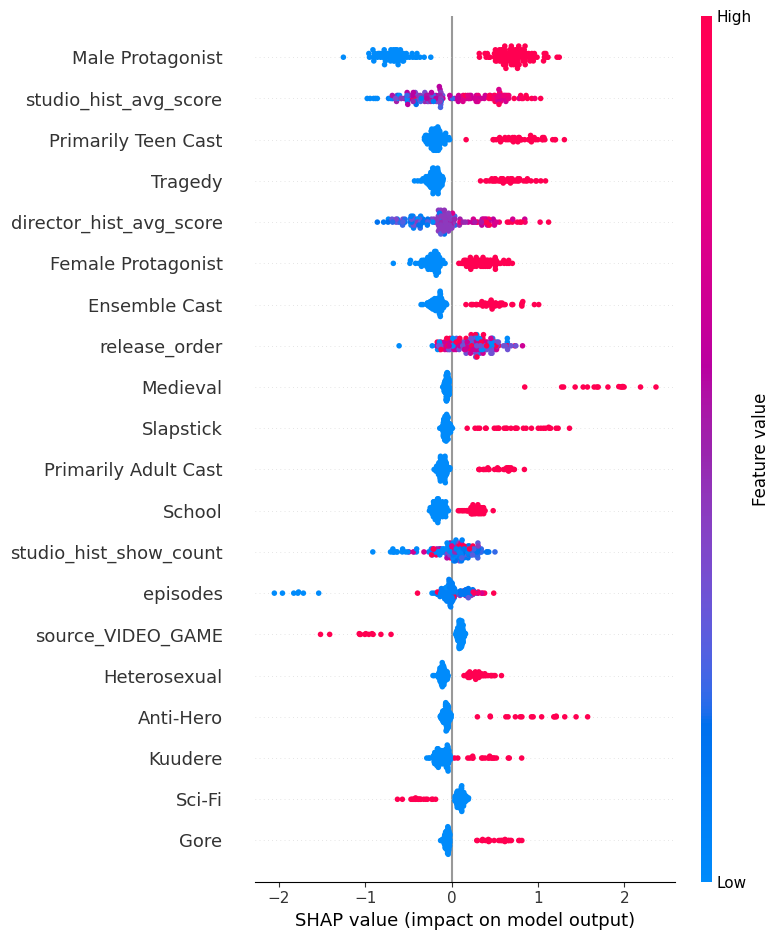

In [49]:
explanation = shap.Explanation(shap_values, feature_names=X_val.columns)

# Bar plot (now works)
#shap.plots.bar(explanation, max_display=20)

# Summary plot (accepts array directly)
shap.summary_plot(shap_values, X_val, max_display=20)

In [24]:
importance.loc[['source_MANGA', 'source_ORIGINAL', 'source_LIGHT_NOVEL']]

source_MANGA          23
source_ORIGINAL        9
source_LIGHT_NOVEL    33
dtype: int32

In [47]:
#  Define the parameter grid 
param_grid_lgb = {
    'n_estimators': [100, 150, 200, 300, 400],
    'max_depth': [4, 6, 8, 10],
    'num_leaves': [20, 40, 60, 80],
    'learning_rate': [0.05, 0.1, 0.15],
    'min_child_samples': [10, 20, 30],
    'reg_alpha': [0.0, 0.1, 0.5],
    'reg_lambda': [0.0, 0.1, 0.5]
}

search_lgb = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_grid_lgb,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

search_lgb.fit(X_train, y_train)

print("Best Params:", search_lgb.best_params_)
print("CV AUC:", search_lgb.best_score_)

#  Init model (set n_estimators high, early stopping will cut it)
lgb_base = lgb.LGBMClassifier(
    n_estimators=1000,  # high enough for early stopping
    scale_pos_weight=scale,
    random_state=42,
    verbosity=-1
)



#  Retrain (again, high n_estimators)
best = search_lgb.best_params_
model_lgb_tuned = lgb.LGBMClassifier(
    **best,
      
    scale_pos_weight=scale,
    random_state=42
)
model_lgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30)]
)

Best Params: {'reg_lambda': 0.1, 'reg_alpha': 0.5, 'num_leaves': 80, 'n_estimators': 200, 'min_child_samples': 30, 'max_depth': 4, 'learning_rate': 0.05}
CV AUC: 0.7582139418449833
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[12]	valid_0's binary_logloss: 0.437737


LGBMClassifier(learning_rate=0.05, max_depth=4, min_child_samples=30,
               n_estimators=200, num_leaves=80, random_state=42, reg_alpha=0.5,
               reg_lambda=0.1, scale_pos_weight=6.034574468085107)

In [27]:


# Best params from RandomizedSearchCV
best_params = {
    'boosting_type': 'gbdt',
    'num_leaves': 80,
    'max_depth': 4,
    'learning_rate': 0.05,
    'n_estimators': 200,
    'min_child_samples': 30,
    'reg_alpha': 0.5,
    'reg_lambda': 0.1,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'scale_pos_weight': scale,
    'random_state': 42,
    'verbosity': -1
}

# 1. Train with best params (no CV, use full train set)
model_tuned = lgb.LGBMClassifier(**best_params)
model_tuned.fit(X_train, y_train)

# 2. Predict on test
y_pred = model_tuned.predict(X_test)
y_proba = model_tuned.predict_proba(X_test)[:, 1]

# 3. Results
print("=== Tuned LightGBM Results (Test 2023+) ===")
print(classification_report(y_test, y_pred, target_names=['Not Hit', 'Hit']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba):.3f}")

# 4. Optional: Feature importance
importance = pd.Series(model_tuned.feature_importances_, index=X_train.columns)
print("\nTop 10 features:")
print(importance.sort_values(ascending=False).head(10))

=== Tuned LightGBM Results (Test 2023+) ===
              precision    recall  f1-score   support

     Not Hit       0.92      0.75      0.83       317
         Hit       0.40      0.71      0.51        72

    accuracy                           0.75       389
   macro avg       0.66      0.73      0.67       389
weighted avg       0.82      0.75      0.77       389

AUC-ROC: 0.850
PR-AUC: 0.614

Top 10 features:
release_order               118
director_hist_avg_score     117
studio_hist_avg_score       102
episodes                     97
studio_hist_show_count       71
Primarily Teen Cast          50
Female Protagonist           41
director_hist_show_count     39
Ensemble Cast                38
Anti-Hero                    34
dtype: int32


In [28]:
# 1. Get predicted probabilities for the validation set using the tuned model
probs_val = model_tuned.predict_proba(X_val)[:, 1]

# 2. Define range of thresholds to test (0.30 to 0.80, step 0.02)
thresholds = np.arange(0.3, 0.8, 0.02)

# 3. Initialize variables to track the best threshold
best_precision = 0
best_thresh = 0.5

# 4. Loop through each threshold
for t in thresholds:
    # Convert probabilities to binary predictions using current threshold
    preds = (probs_val >= t).astype(int)
    # Calculate precision
    p = precision_score(y_val, preds)
    # Keep track of the best precision and its threshold
    if p > best_precision:
        best_precision = p
        best_thresh = t

# 5. Print the threshold that maximizes precision
print(f"Best threshold for Precision: {best_thresh:.2f}")
print(f"Validation Precision at this threshold: {best_precision:.3f}")

# 6. Apply best threshold to get final validation predictions
preds_val_opt = (probs_val >= best_thresh).astype(int)
print(f"Validation Recall: {recall_score(y_val, preds_val_opt):.3f}")
print(f"Validation F1: {f1_score(y_val, preds_val_opt):.3f}")

Best threshold for Precision: 0.78
Validation Precision at this threshold: 0.714
Validation Recall: 0.645
Validation F1: 0.678


In [29]:
# === LOCKED: FINAL TEST WITH TUNED MODEL & OPTIMIZED THRESHOLD ===
# Threshold found on validation: 0.78
FINAL_THRESHOLD = 0.78

y_pred_final = (model_tuned.predict_proba(X_test)[:, 1] >= FINAL_THRESHOLD).astype(int)

print("="*50)
print(" FINAL TEST PERFORMANCE (2023-2024) ")
print("="*50)
print(classification_report(y_test, y_pred_final, target_names=['Not Hit', 'Hit']))
print(f"Final Precision (Hit): {precision_score(y_test, y_pred_final):.3f}")
print(f"Final Recall (Hit): {recall_score(y_test, y_pred_final):.3f}")
print(f"Final F1 (Hit): {f1_score(y_test, y_pred_final):.3f}")
print(f"Final PR-AUC: {average_precision_score(y_test, model_tuned.predict_proba(X_test)[:, 1]):.3f}")

 FINAL TEST PERFORMANCE (2023-2024) 
              precision    recall  f1-score   support

     Not Hit       0.89      0.93      0.91       317
         Hit       0.61      0.49      0.54        72

    accuracy                           0.85       389
   macro avg       0.75      0.71      0.73       389
weighted avg       0.84      0.85      0.84       389

Final Precision (Hit): 0.614
Final Recall (Hit): 0.486
Final F1 (Hit): 0.543
Final PR-AUC: 0.614


## ===============VERIFY====================

In [39]:
def predict_manual(genres, tags, source, season, episodes, duration, release_order, start_month,
                   studio_avg, director_avg, studio_count, director_count,
                   is_debut_studio=0, is_debut_director=0,
                   model=model_tuned, threshold=0.78):
    
    anime = {
        'genres': genres,
        'tags': tags,
        'source': source,
        'season': season,
        'episodes': episodes,
        'duration': duration,
        'release_order': release_order,
        'start_month': start_month,
        'studio_hist_avg_score': studio_avg,
        'director_hist_avg_score': director_avg,
        'studio_hist_show_count': studio_count,
        'director_hist_show_count': director_count,
        'is_debut_studio': is_debut_studio,
        'is_debut_director': is_debut_director
    }
    
    result = predict_anime(anime, model, threshold)
    return result

In [40]:
sakamoto = {
    'genres': 'Action|Comedy',
    'tags': 'Assassins|Urban|Found Family|Konbini|Crime|Primarily Adult Cast|Super Power|Male Protagonist|Family Life|Slapstick|Gangs|Guns|Shounen|Gore|Urban Fantasy|Espionage|Yakuza|Triads|Gambling',
    'source': 'MANGA',
    'season': 'WINTER',
    'episodes': 11,
    'duration': 24,
    'release_order': 8300,  # 2025 Winter
    'start_month': 1,
    'studio_hist_avg_score': 66.0,  # TMS Entertainment
    'director_hist_avg_score': 70.0,  # Masaki Watanabe
    'studio_hist_show_count': 30,
    'director_hist_show_count': 8,
    'is_debut_studio': 0,
    'is_debut_director': 0
}
result = predict_anime(sakamoto, model_tuned, threshold=0.78)
print(f"Hit probability: {result['probability']:.2%}")
print(f"Prediction: {result['prediction']}")

Hit probability: 70.81%
Prediction: Not Hit


In [41]:
wandance = {
    'genres': 'Drama|Sports',
    'tags': 'Dancing|Disability|School Club|Seinen|School|CGI|Male Protagonist|Female Protagonist|Rural|Basketball',
    'source': 'MANGA',
    'season': 'FALL',
    'episodes': 12,
    'duration': 23,
    'release_order': 8350,
    'start_month': 10,
    'studio_hist_avg_score': 78.0,  # MADHOUSE
    'director_hist_avg_score': 60.0,  # Michiya Katou
    'studio_hist_show_count': 100,
    'director_hist_show_count': 5,
    'is_debut_studio': 0,
    'is_debut_director': 0
}
result = predict_anime(wandance, model_tuned, threshold=0.78)
print(f"Hit probability: {result['probability']:.2%}")
print(f"Prediction: {result['prediction']}")

Hit probability: 12.71%
Prediction: Not Hit


In [42]:
beginning = {
    'genres': 'Action|Adventure|Fantasy',
    'tags': 'Magic|Reincarnation|Isekai|Male Protagonist|War|Medieval|Cultivation|CGI|Travel|Elf|Dragons|Heterosexual|Female Harem|Swordplay|Time Skip',
    'source': 'OTHER',
    'season': 'SPRING',
    'episodes': 24,
    'duration': 23,
    'release_order': 8320,
    'start_month': 4,
    'studio_hist_avg_score': 60.0,  # studio A-CAT
    'director_hist_avg_score': 70.0,  # Keitarou Motonaga
    'studio_hist_show_count': 15,
    'director_hist_show_count': 10,
    'is_debut_studio': 0,
    'is_debut_director': 0
}
result = predict_anime(beginning, model_tuned, threshold=0.78)
print(f"Hit probability: {result['probability']:.2%}")
print(f"Prediction: {result['prediction']}")

Hit probability: 66.15%
Prediction: Not Hit


In [43]:
grisaia = {
    'genres': 'Action',
    'tags': 'Primarily Female Cast|Guns|Amnesia|Military|Tragedy|War|Gore|Assassins|Terrorism|Time Skip|Swordplay|LGBTQ+ Themes',
    'source': 'VISUAL_NOVEL',
    'season': 'WINTER',
    'episodes': 13,
    'duration': 25,
    'release_order': 8310,
    'start_month': 1,
    'studio_hist_avg_score': 65.0,  # Bibury Animation Studios
    'director_hist_avg_score': 62.0,  # Kousuke Murayama
    'studio_hist_show_count': 10,
    'director_hist_show_count': 8,
    'is_debut_studio': 0,
    'is_debut_director': 0
}
result = predict_anime(grisaia, model_tuned, threshold=0.78)
print(f"Hit probability: {result['probability']:.2%}")
print(f"Prediction: {result['prediction']}")

Hit probability: 3.40%
Prediction: Not Hit


=== TOP 20 FEATURES (TUNED MODEL) ===
release_order               118
director_hist_avg_score     117
studio_hist_avg_score       102
episodes                     97
studio_hist_show_count       71
Primarily Teen Cast          50
Female Protagonist           41
director_hist_show_count     39
Ensemble Cast                38
Anti-Hero                    34
Philosophy                   33
Survival                     32
Medieval                     31
Heterosexual                 30
Urban                        30
Male Protagonist             29
Slapstick                    29
Tsundere                     27
Gore                         25
Primarily Adult Cast         25
dtype: int32


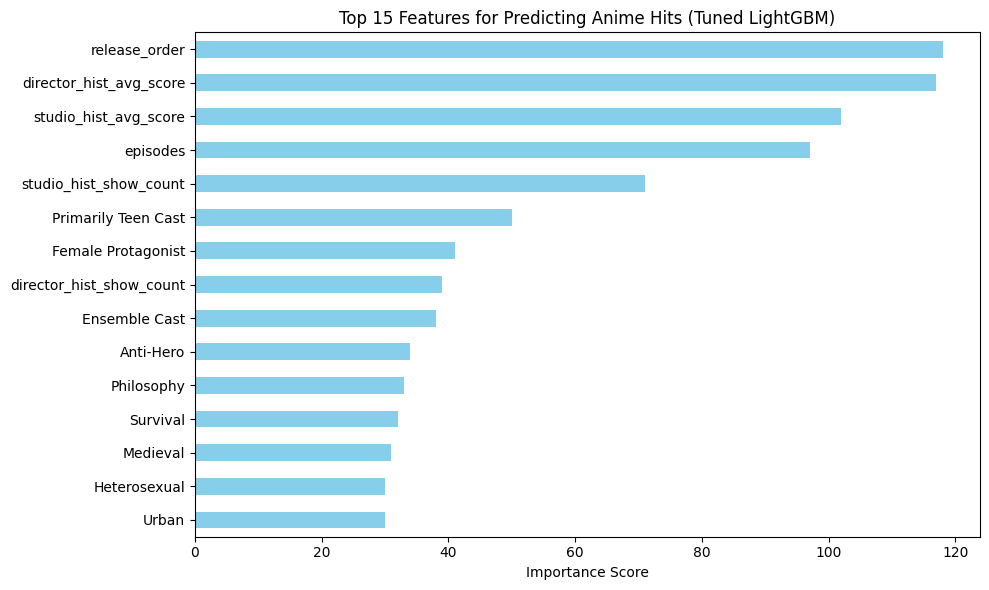

In [44]:
# 1. Get importance scores from the TUNED model
importance = pd.Series(model_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# 2. Print the top 20 features
print("=== TOP 20 FEATURES (TUNED MODEL) ===")
print(importance.head(20))

# 3. Plot the top 15
plt.figure(figsize=(10, 6))
importance.head(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Features for Predicting Anime Hits (Tuned LightGBM)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()  # Highest at the top
plt.tight_layout()
plt.show()

In [48]:
opm_s3 = {
    'genres': 'Action|Comedy|Sci-Fi|Supernatural',
    'tags': 'Superhero|Parody|Super Power|Satire|Martial Arts|Male Protagonist|Seinen|Anti-Hero|Urban Fantasy|Surreal Comedy|Primarily Adult Cast|Primarily Male Cast|Kaiju|Gods|Fitness|Cyborg',
    'source': 'MANGA',
    'season': 'FALL',
    'episodes': 12,
    'duration': 24,
    'release_order': 8200,
    'start_month': 10,
    'studio_hist_avg_score': 70.77,   # J.C. Staff avg dataset
    'director_hist_avg_score': 59.00, # Shinpei Nagai estimated
    'studio_hist_show_count': 114,    # J.C. Staff count from dataset
    'director_hist_show_count': 5,    # Shinpei Nagai count from dataset
    'is_debut_studio': 0,
    'is_debut_director': 0
}

result = predict_anime(opm_s3, model_tuned, threshold=0.78)
print(f"One-Punch Man S3 -> Prob: {result['probability']:.2%} | Pred: {result['prediction']}")

One-Punch Man S3 -> Prob: 44.08% | Pred: Not Hit


In [45]:
# ============================================================
# 2025 ANIME PREDICTIONS – INDIVIDUAL SHOWS
# ============================================================

# 1. Dororo (2019 hit – used as a benchmark)
dororo = {
    'genres': 'Action|Adventure|Drama|Supernatural',
    'tags': 'Demons|Revenge|Disability|Curses|Tragedy|Swordplay|Samurai|Estranged Family|Youkai|Orphan|Anti-Hero|War|Parenthood|Male Protagonist|Historical|Travel|Rural|Urban Fantasy|Gore|Philosophy|Female Protagonist|Crossdressing|Tomboy|Body Horror|Episodic|Kuudere|Shounen|Primarily Male Cast|Primarily Adult Cast|Ghost|Cannibalism|Prostitution|Heterosexual|Nun|Body Image|Martial Arts',
    'source': 'MANGA',
    'season': 'WINTER',
    'episodes': 24,
    'duration': 24,
    'release_order': 8076,
    'start_month': 1,
    'studio_hist_avg_score': 72.77,
    'director_hist_avg_score': 72.75,
    'studio_hist_show_count': 43,
    'director_hist_show_count': 12,
    'is_debut_studio': 0,
    'is_debut_director': 0
}

# 2. Orb: On the Movements of the Earth (2024 hit)
orb = {
    'genres': 'Drama',
    'tags': 'Astronomy|Philosophy|Religion|Ensemble Cast|Seinen|Foreign|Historical|Tragedy|Medieval|Time Skip|Fugitive|Conspiracy|Torture|Primarily Male Cast|Female Protagonist|Male Protagonist|Meta|Politics|Suicide|Gore|Swordplay|Assassins|Alternate Universe|Rural',
    'source': 'MANGA',
    'season': 'FALL',
    'episodes': 25,
    'duration': 25,
    'release_order': 8099,
    'start_month': 10,
    'studio_hist_avg_score': 70.30,
    'director_hist_avg_score': 77.67,
    'studio_hist_show_count': 128,
    'director_hist_show_count': 3,
    'is_debut_studio': 0,
    'is_debut_director': 0
}

# 3. BanG Dream! Ave Mujica (2025 flop)
ave_mujica = {
    'genres': 'Drama|Music|Psychological',
    'tags': 'Band|Primarily Female Cast|Female Protagonist|Primarily Teen Cast|Tragedy|Dissociative Identities|Estranged Family|Full CGI|LGBTQ+ Themes|Yuri|Metal Music|Acting|Rock Music|Musical Theater|Incest|Disability|Ensemble Cast|Urban|Orphan|Ojou-sama|Anti-Hero|Adoption|Yandere|Kuudere|Tsundere',
    'source': 'OTHER',
    'season': 'WINTER',
    'episodes': 13,
    'duration': 24,
    'release_order': 8100,
    'start_month': 1,
    'studio_hist_avg_score': 67.17,
    'director_hist_avg_score': 73.00,
    'studio_hist_show_count': 12,
    'director_hist_show_count': 5,
    'is_debut_studio': 0,
    'is_debut_director': 0
}

# 4. Lazarus (2025 flop)
lazarus = {
    'genres': 'Action|Sci-Fi|Thriller',
    'tags': 'Ensemble Cast|Crime|Medicine|Urban|Environmental|Fugitive|Drugs|Found Family|Anti-Hero|Male Protagonist|Philosophy|Episodic|Parkour|Cyberpunk|Espionage|Guns|Foreign|Homeless|LGBTQ+ Themes|Assassins|Military|Rescue|Death Game|Prison|Artificial Intelligence|Cult|Circus|Dissociative Identities|Bisexual|Gore|Crossdressing',
    'source': 'ORIGINAL',
    'season': 'SPRING',
    'episodes': 13,
    'duration': 24,
    'release_order': 8101,
    'start_month': 4,
    'studio_hist_avg_score': 72.77,
    'director_hist_avg_score': 79.33,
    'studio_hist_show_count': 43,
    'director_hist_show_count': 6,
    'is_debut_studio': 0,
    'is_debut_director': 0
}



print("="*60)
print("2025 ANIME PREDICTIONS (Threshold = 0.78)")
print("="*60)

# Dororo
res = predict_anime(dororo, model_tuned, threshold=0.78)
print(f"Dororo (2019 Hit Benchmark)")
print(f"  -> Probability: {res['probability']:.2%}")
print(f"  -> Prediction:  {res['prediction']}")
print(f"  -> Actual Hit:  1 (benchmark)")
print("-"*40)

# Orb
res = predict_anime(orb, model_tuned, threshold=0.78)
print(f"Orb: On the Movements of the Earth (2024 Hit)")
print(f"  -> Probability: {res['probability']:.2%}")
print(f"  -> Prediction:  {res['prediction']}")
print(f"  -> Actual Hit:  1 (critical acclaim)")
print("-"*40)

# Ave Mujica
res = predict_anime(ave_mujica, model_tuned, threshold=0.78)
print(f"BanG Dream! Ave Mujica (2025 Flop)")
print(f"  -> Probability: {res['probability']:.2%}")
print(f"  -> Prediction:  {res['prediction']}")
print(f"  -> Actual Hit:  0 (disappointing reception)")
print("-"*40)

# Lazarus
res = predict_anime(lazarus, model_tuned, threshold=0.78)
print(f"Lazarus (2025 Flop)")
print(f"  -> Probability: {res['probability']:.2%}")
print(f"  -> Prediction:  {res['prediction']}")
print(f"  -> Actual Hit:  0 (overshadowed)")
print("-"*40)

print("="*60)

2025 ANIME PREDICTIONS (Threshold = 0.78)
Dororo (2019 Hit Benchmark)
  -> Probability: 97.58%
  -> Prediction:  Hit
  -> Actual Hit:  1 (benchmark)
----------------------------------------
Orb: On the Movements of the Earth (2024 Hit)
  -> Probability: 90.77%
  -> Prediction:  Hit
  -> Actual Hit:  1 (critical acclaim)
----------------------------------------
BanG Dream! Ave Mujica (2025 Flop)
  -> Probability: 26.06%
  -> Prediction:  Not Hit
  -> Actual Hit:  0 (disappointing reception)
----------------------------------------
Lazarus (2025 Flop)
  -> Probability: 83.31%
  -> Prediction:  Hit
  -> Actual Hit:  0 (overshadowed)
----------------------------------------
